# Program - plot-var_2d_time_lev-cn_xy_flexible-TaiESM_hindcast

**Purpose**

read TaiESM hindcast data and make plots for time-level dimension, including contour, time series, and profiles.

**Content**
- read data: Read TaiESM hindcast data at a grid point (lat, lon) and selected time range 
- set characteristics for plots, such as time tick mark labels, color map, etc.
- plot time series (xy_series)
- plot profiles for N variables at one time step (xy_profile_Nv1t)
- plot profiles for 1 variable at multiple time step (xy_profile_1vNt)
- plot time-level cross section (cn_time_level)

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 
March 2025

**Reference program:**
Thanks for chatGPT.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc
#import read_data as read_data   ## on GFDL PP/AN
import read_data_big as read_data    ## on my Mac

#--- silence dask large chunk and silence the warning.
import dask
dask.config.set(**{'array.slicing.split_large_chunks': False})

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

# Functions

## plot_box

In [2]:
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

def plot_box(ax, region="DYCOMS", edgecolor="cyan", linewidth=2):

    if region == "DYCOMS":
        lowerlat = 30.0
        upperlat = 32.2
        lowerlon = 236.2
        upperlon = 240.0

    lon_range = upperlon - lowerlon
    lat_range = upperlat - lowerlat

    rect = mpatches.Rectangle(
        (lowerlon, lowerlat),
        lon_range,
        lat_range,
        facecolor="none",
        edgecolor=edgecolor,
        linewidth=linewidth,
        transform=ccrs.PlateCarree(),
    )

    ax.add_patch(rect)

    return rect

In [72]:
import numpy as np

def plot_points(
    ax,
    ds,
    *,
    color="cyan",
    marker="o",
    size=10,
    transform=None,
    **kwargs,
):
    """
    Plot all latitude/longitude grid points.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Cartopy axis.

    ds : xr.Dataset or xr.DataArray
        Object containing 1-D 'lat' and 'lon' coordinates.

    color : str, default="cyan"
        Marker color.

    marker : str, default="o"
        Marker style.

    size : float, default=10
        Marker size (passed to `s` in scatter).

    transform : cartopy.crs.CRS, optional
        Coordinate reference system. If None, PlateCarree() is used.

    **kwargs
        Additional keyword arguments passed to `ax.scatter()`.
    """

    import cartopy.crs as ccrs

    if transform is None:
        transform = ccrs.PlateCarree()

    lon2d, lat2d = np.meshgrid(ds["lon"], ds["lat"])

    ax.scatter(
        lon2d,
        lat2d,
        s=size,
        c=color,
        marker=marker,
        transform=transform,
        **kwargs,
    )


## get_region_extent

In [3]:
def get_region_extent(region, padding=2):

    if region == "DYCOMS":
        lowerlat = 30.0
        upperlat = 32.2
        lowerlon = 236.2
        upperlon = 240.0

    return [
        lowerlon-padding,
        upperlon+padding,
        lowerlat-padding,
        upperlat+padding,
    ]

## plot_cn_map

In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

def plot_cn_map(
    ax,
    da,
    method="contourf",
    levels=21,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
    norm=None,
    extend="both",
    title=None,
    add_time_to_title=True,
    cbar=True,
    cbar_label=None,
    cbar_orientation="horizontal",
    cbar_pad=0.08,
    cbar_shrink=0.9,
    extent=None,
    extent_padding=0.0,
    add_coastlines=True,
    coastline_linewidth=0.8,
    add_borders=False,
    border_linewidth=0.5,
    add_gridlines=True,
    draw_labels=True,
    panel_label=None,
    panel_label_position=(0.02, 0.98),
    plot_kwargs=None,
):
    """
    Plot a 2-D latitude-longitude xarray DataArray on an existing
    Cartopy axis using contourf or pcolormesh.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Existing Cartopy axis.

    da : xarray.DataArray
        Two-dimensional latitude-longitude DataArray.

    method : {"contourf", "pcolormesh"}, default="contourf"
        Plotting method.

    levels : int or array-like, default=21
        For contourf:
        - If an integer, it specifies the number of contour boundaries.
        - If array-like, it specifies the explicit contour boundaries.

        For pcolormesh, levels is ignored unless a BoundaryNorm is
        supplied through norm.

    vmin, vmax : float, optional
        Minimum and maximum values of the color scale.

        For contourf, when levels is an integer and both vmin and vmax
        are supplied, levels are generated using:

            np.linspace(vmin, vmax, levels)

        For pcolormesh, vmin and vmax directly control the color scale.

    cmap : str or matplotlib.colors.Colormap, default="RdBu_r"
        Colormap.

    norm : matplotlib.colors.Normalize, optional
        Color normalization, such as TwoSlopeNorm, LogNorm, or
        BoundaryNorm.

        Do not normally provide norm together with vmin and vmax.

    extend : {"neither", "both", "min", "max"}, default="both"
        Colorbar extension. Primarily used by contourf.

    title : str, optional
        Plot title. If None, da.name is used.

    add_time_to_title : bool, default=True
        Append the scalar time coordinate to the title in the format
        yyyy-mm-dd-hh:mm.

    cbar : bool, default=False
        Add an individual colorbar to this axis.

    cbar_label : str, optional
        Colorbar label. If None, da.attrs["units"] is used.

    cbar_orientation : {"horizontal", "vertical"}
        Colorbar orientation.

    cbar_pad : float, default=0.08
        Distance between the axis and colorbar.

    cbar_shrink : float, default=0.9
        Relative colorbar length.

    extent : sequence, optional
        Map extent:

            [lon_min, lon_max, lat_min, lat_max]

        If None, the full latitude and longitude range of da is used.

    extent_padding : float, default=0.0
        Padding in degrees added around the automatically determined
        DataArray extent.

    add_coastlines : bool, default=True
        Add coastlines.

    coastline_linewidth : float, default=0.8
        Coastline width.

    add_borders : bool, default=False
        Add national borders.

    border_linewidth : float, default=0.5
        Border width.

    add_gridlines : bool, default=True
        Add longitude-latitude gridlines.

    draw_labels : bool, default=True
        Add longitude-latitude labels.

    panel_label : str, optional
        Panel label, such as "(a)".

    panel_label_position : tuple, default=(0.02, 0.98)
        Panel-label position in axes coordinates.

    plot_kwargs : dict, optional
        Extra arguments passed to contourf or pcolormesh.

        Examples
        --------
        For pcolormesh:

            {"shading": "auto", "rasterized": True}

        For contourf:

            {"antialiased": False}

    Returns
    -------
    mappable
        The QuadContourSet from contourf or QuadMesh from pcolormesh.

    cbar_obj
        Colorbar object if cbar=True; otherwise None.
    """

    # ------------------------------------------------------------
    # Check input
    # ------------------------------------------------------------
    if not isinstance(da, xr.DataArray):
        raise TypeError("da must be an xarray.DataArray.")

    if da.ndim != 2:
        raise ValueError(
            f"da must be 2-D, but its dimensions are {da.dims}."
        )

    method = method.lower()

    if method not in {"contourf", "pcolormesh"}:
        raise ValueError(
            "method must be either 'contourf' or 'pcolormesh'."
        )

    lat_name, lon_name = _find_lat_lon_names(da)

    if plot_kwargs is None:
        plot_kwargs = {}
    else:
        # Copy the dictionary so the original is not modified
        plot_kwargs = plot_kwargs.copy()

    # ------------------------------------------------------------
    # Avoid passing vmin/vmax together with norm
    # ------------------------------------------------------------
    if norm is not None and (vmin is not None or vmax is not None):
        raise ValueError(
            "Use either norm or vmin/vmax, not both."
        )

    # ------------------------------------------------------------
    # Set color levels and normalization
    # ------------------------------------------------------------
    discrete_levels = not np.isscalar(levels)
    
    if discrete_levels:
        levels = np.asarray(levels)
    
        if levels.ndim != 1 or len(levels) < 2:
            raise ValueError(
                "levels must be a one-dimensional array with at least "
                "two boundaries."
            )
    
        if np.any(np.diff(levels) <= 0):
            raise ValueError(
                "levels must be strictly increasing."
            )
    
    if norm is not None and (vmin is not None or vmax is not None):
        raise ValueError(
            "Use either norm or vmin/vmax, not both."
        )
    
    # ------------------------------------------------------------
    # Draw the data
    # ------------------------------------------------------------
    if method == "contourf":
    
        contour_levels = levels
    
        if (
            np.isscalar(levels)
            and vmin is not None
            and vmax is not None
        ):
            contour_levels = np.linspace(
                vmin,
                vmax,
                int(levels),
            )
    
        contourf_args = {
            "levels": contour_levels,
            "cmap": cmap,
            "extend": extend,
            "transform": ccrs.PlateCarree(),
        }
    
        if norm is not None:
            contourf_args["norm"] = norm
    
        contourf_args.update(plot_kwargs)
    
        mappable = ax.contourf(
            da[lon_name],
            da[lat_name],
            da,
            **contourf_args,
        )
    
    elif method == "pcolormesh":
    
        plot_kwargs.setdefault("shading", "auto")
    
        pcolormesh_args = {
            "cmap": cmap,
            "transform": ccrs.PlateCarree(),
        }
    
        if discrete_levels:
            if norm is None:
                norm = BoundaryNorm(
                    levels,
                    ncolors=plt.get_cmap(cmap).N,
                    clip=False,
                    extend=extend,
                )
    
            pcolormesh_args["norm"] = norm
    
        elif norm is not None:
            pcolormesh_args["norm"] = norm
    
        else:
            pcolormesh_args["vmin"] = vmin
            pcolormesh_args["vmax"] = vmax
    
        pcolormesh_args.update(plot_kwargs)
    
        mappable = ax.pcolormesh(
            da[lon_name],
            da[lat_name],
            da,
            **pcolormesh_args,
        )

    # ------------------------------------------------------------
    # Set the map extent
    # ------------------------------------------------------------
    if extent is None:
        lon_min = float(da[lon_name].min().values)
        lon_max = float(da[lon_name].max().values)
        lat_min = float(da[lat_name].min().values)
        lat_max = float(da[lat_name].max().values)

        extent = [
            lon_min - extent_padding,
            lon_max + extent_padding,
            lat_min - extent_padding,
            lat_max + extent_padding,
        ]

    ax.set_extent(
        extent,
        crs=ccrs.PlateCarree(),
    )

    # ------------------------------------------------------------
    # Map features
    # ------------------------------------------------------------
    if add_coastlines:
        ax.coastlines(
            linewidth=coastline_linewidth,
        )

    if add_borders:
        ax.add_feature(
            cfeature.BORDERS,
            linewidth=border_linewidth,
        )

    if add_gridlines:
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=draw_labels,
            linewidth=0.5,
            linestyle="--",
            alpha=0.5,
        )

        if draw_labels:
            gl.top_labels = False
            gl.right_labels = False

    # ------------------------------------------------------------
    # Title and time
    # ------------------------------------------------------------
    if title is None:
        title = da.name or ""

    if add_time_to_title and "time" in da.coords:
        time_string = _format_time(da["time"])

        if time_string:
            if title:
                title = f"{title}\n{time_string}"
            else:
                title = time_string

    ax.set_title(title)

    # ------------------------------------------------------------
    # Panel label
    # ------------------------------------------------------------
    if panel_label is not None:
        ax.text(
            panel_label_position[0],
            panel_label_position[1],
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=12,
            fontweight="bold",
            zorder=10,
        )

    # ------------------------------------------------------------
    # Individual colorbar
    # ------------------------------------------------------------
    cbar_obj = None

    if cbar:
        cbar_obj = ax.figure.colorbar(
            mappable,
            ax=ax,
            orientation=cbar_orientation,
            pad=cbar_pad,
            shrink=cbar_shrink,
            extend=extend if method == "pcolormesh" else None,
        )

        if cbar_label is None:
            cbar_label = da.attrs.get("units", "")

        if cbar_label:
            cbar_obj.set_label(cbar_label)

    return mappable, cbar_obj


def _find_lat_lon_names(da):
    """
    Identify latitude and longitude coordinate names.
    """

    lat_candidates = [
        "lat",
        "latitude",
        "LAT",
        "Latitude",
    ]

    lon_candidates = [
        "lon",
        "longitude",
        "LON",
        "Longitude",
    ]

    lat_name = next(
        (
            name
            for name in lat_candidates
            if name in da.coords
        ),
        None,
    )

    lon_name = next(
        (
            name
            for name in lon_candidates
            if name in da.coords
        ),
        None,
    )

    if lat_name is None or lon_name is None:
        raise ValueError(
            "Could not identify latitude and longitude coordinates. "
            f"Available coordinates are {list(da.coords)}."
        )

    return lat_name, lon_name


def _format_time(time_coord):
    """
    Format a scalar xarray time coordinate as yyyy-mm-dd-hh:mm.

    Supports cftime, datetime, pandas Timestamp, and numpy.datetime64.
    """

    if time_coord.size != 1:
        return ""

    time_value = time_coord.values

    # Convert a zero-dimensional NumPy array to a scalar
    if isinstance(time_value, np.ndarray):
        time_value = time_value.item()

    # cftime, datetime, or pandas Timestamp
    if hasattr(time_value, "strftime"):
        return time_value.strftime("%Y-%m-%d-%H:%M")

    # numpy.datetime64
    try:
        return np.datetime_as_string(
            np.datetime64(time_value),
            unit="m",
        ).replace("T", "-")
    except (TypeError, ValueError):
        return str(time_value)

## get_time_indices_from_strings

In [5]:
import cftime
import numpy as np
import xarray as xr
from typing import List, Union

def get_time_indices_from_strings(
    data: Union[xr.Dataset, xr.DataArray],
    time_strs: List[str],
    time_dim: str = "time"
) -> List[int]:
    """
    Given an xarray Dataset or DataArray and a list of time strings in the format 'YYYYMMDD_HHMMSS',
    return the indices of matching times in the dataset's time coordinate.

    Parameters:
        data (xr.Dataset or xr.DataArray): Input dataset or dataarray.
        time_strs (List[str]): List of time strings in 'YYYYMMDD_HHMMSS' format.
        time_dim (str): Name of the time dimension (default is "time").

    Returns:
        List[int]: Indices of the matching times.
    """
    # Convert time strings to cftime.DatetimeNoLeap objects
    target_times = [
        cftime.DatetimeNoLeap(
            int(s[:4]), int(s[4:6]), int(s[6:8]),
            int(s[9:11]), int(s[11:13]), int(s[13:15]),
            has_year_zero=True
        ) for s in time_strs
    ]

    ds_times = data[time_dim].values
    indices = []

    for t_str, t_obj in zip(time_strs, target_times):
        if t_obj in ds_times:
            idx = np.where(ds_times == t_obj)[0][0]
            indices.append(idx)
        else:
            print(f"Warning: Time '{t_str}' not found in {time_dim} coordinate.")

    return indices

## find_nearest_indices

In [6]:
from datetime import datetime

import numpy as np
import xarray as xr


def find_nearest_indices(
    da: xr.DataArray,
    target_value: float,
    time: str,
    lat: float,
    lon: float,
):
    """
    Find the nearest time, lev, lat, and lon indices.

    Parameters
    ----------
    da : xr.DataArray
        DataArray containing the dimensions:
        time, lev, lat, and lon.

        The values along the selected vertical profile are used to
        find the level nearest to `target_value`.

    target_value : float
        Target value along the vertical profile.
        For geopotential height, this would be the target height in m.

    time : str
        Target time in the format "yyyymmdd_hhmmss".

        Example:
            "20010708_210000"

    lat : float
        Target latitude.

    lon : float
        Target longitude.

    Returns
    -------
    itime, ilev, ilat, ilon : tuple of int
        Integer indices for time, lev, lat, and lon.
    """

    required_dims = {"time", "lev", "lat", "lon"}
    missing_dims = required_dims.difference(da.dims)

    if missing_dims:
        raise ValueError(
            f"Missing dimensions: {sorted(missing_dims)}. "
            f"Available dimensions: {list(da.dims)}"
        )

    # ---------------------------------------------------------
    # Parse requested time
    # ---------------------------------------------------------
    try:
        requested_time = datetime.strptime(
            time,
            "%Y%m%d_%H%M%S",
        )
    except ValueError as error:
        raise ValueError(
            "time must use the format 'yyyymmdd_hhmmss', "
            "for example '20010708_210000'."
        ) from error

    # ---------------------------------------------------------
    # Load coordinates as NumPy arrays
    # ---------------------------------------------------------
    time_values = da["time"].values
    lat_values = np.asarray(da["lat"].values)
    lon_values = np.asarray(da["lon"].values)

    # ---------------------------------------------------------
    # Find the nearest time index
    # ---------------------------------------------------------
    sample_time = time_values[0]

    if hasattr(sample_time, "calendar"):
        # cftime coordinate
        target_time = type(sample_time)(
            requested_time.year,
            requested_time.month,
            requested_time.day,
            requested_time.hour,
            requested_time.minute,
            requested_time.second,
        )

        # Convert time differences to seconds
        time_difference = np.array(
            [
                abs((model_time - target_time).total_seconds())
                for model_time in time_values
            ]
        )

    else:
        # NumPy datetime64 coordinate
        target_time = np.datetime64(requested_time)

        time_difference = np.abs(
            time_values.astype("datetime64[ns]")
            - target_time.astype("datetime64[ns]")
        ).astype("timedelta64[ns]").astype(np.int64)

    itime = int(np.argmin(time_difference))

    # ---------------------------------------------------------
    # Find nearest latitude index
    # ---------------------------------------------------------
    lat_difference = np.abs(lat_values - lat)
    ilat = int(np.nanargmin(lat_difference))

    # ---------------------------------------------------------
    # Find nearest longitude index
    # ---------------------------------------------------------
    # This handles differences such as:
    # requested lon = -122
    # model lon     = 238
    lon_difference = np.abs(
        ((lon_values - lon + 180.0) % 360.0) - 180.0
    )

    ilon = int(np.nanargmin(lon_difference))

    # ---------------------------------------------------------
    # Load only the selected vertical profile
    # ---------------------------------------------------------
    profile = da.isel(
        time=itime,
        lat=ilat,
        lon=ilon,
    )

    # Explicitly evaluate the Dask array and convert to NumPy
    if hasattr(profile.data, "compute"):
        profile_values = profile.data.compute()
    else:
        profile_values = profile.data

    profile_values = np.asarray(profile_values).squeeze()

    if profile_values.ndim != 1:
        raise ValueError(
            "The selected profile must be one-dimensional after "
            "selecting time, lat, and lon. "
            f"Found shape {profile_values.shape}."
        )

    valid = np.isfinite(profile_values)

    if not np.any(valid):
        raise ValueError(
            "The selected vertical profile contains no finite values."
        )

    # ---------------------------------------------------------
    # Find nearest vertical level using NumPy only
    # ---------------------------------------------------------
    difference = np.full(
        profile_values.shape,
        np.inf,
        dtype=float,
    )

    difference[valid] = np.abs(
        profile_values[valid] - target_value
    )

    ilev = int(np.argmin(difference))

    return itime, ilev, ilat, ilon

## select_region_ds

In [103]:
##################
##################
##################
def select_region_ds(ds,
                  region="lat_lon",
                  lat=None, lon=None, 
                 ):

    func_name = "select_ds_region"
    
    #--- given the lat/lon range of a region
    if (region == "NE_CA"):
        #lowerlon=235; upperlon=245; lowerlat=28; upperlat=35
        lowerlon=225; upperlon=250; lowerlat=24; upperlat=40

    elif (region == "DYCOMS"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  236.5  # 123.5W
        upperlon =  240    # 120W

    elif (region == "DYCOMS_entire"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  236    # 123.5W
        upperlon =  240    # 120W

    elif (region == "DYCOMS_entire_east"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  238    # 123.5W
        upperlon =  240    # 120W

    elif (region == "DYCOMS_entire_west"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  236    # 123.5W
        upperlon =  238    # 120W

    elif (region == "DYCOMS_small"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  30   # 29.5N
        upperlat =  32     # 33N
        lowerlon =  236    # 123.5W
        upperlon =  240    # 120W
    
    elif (region == "lat_lon"): 
        if lat is None or lon is None:
            error_msg = f"ERROR: function [{func_name}] needs lat [{lat}] and lon [{lon}] when region='lat_lon'"
            raise KeyError(error_msg)
    
    else:
        lowerlon=-1000; upperlon=1000; lowerlat=-1000; upperlat=1000

    #--- select for in the given region
    if (region == "lat_lon"):
        lat_index, lon_index = get_lat_lon_indexes(ds, lat, lon)
        ds_region = ds.isel(lat=lat_index, lon=lon_index)

    else:
        lon_slice = slice(lowerlon, upperlon)
        lat_slice = slice(lowerlat, upperlat)
        ds_region = ds.sel(lat=lat_slice, lon=lon_slice)
    
    return ds_region

##################
##################
##################
def get_lat_lon_indexes(ds, lat, lon):
    lat_index = abs(ds['lat'] - lat).argmin().item()
    lon_index = abs(ds['lon'] - lon).argmin().item()

    return lat_index, lon_index

#-----------
# do_test
#-----------

do_test="112"
#do_test=False

if (do_test == "111"):
    choice = "custom_Ttend_3hr"
    icdate = "20010710"
    ds1 = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=5)
    
    lat=31.5 ; lon=236.5
    
    ds1_region = select_region_ds(ds1, region="DYCOMS", lat=lat, lon=lon)

#ds1_region

# Plot

## read data

In [7]:
icdate = "20010707"
ss5="00000"
icdata_option = "qq02_macrop_tpdf"
file_dates = 5

choice = "custom_state_3hr"
ds_state_3hr = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates, icdata_option=icdata_option, ss5=ss5)

choice = "custom_2d_1hr"
ds_2d_1hr = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates, icdata_option=icdata_option, ss5=ss5)

In [104]:
#ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_entire")
ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_entire_west")
#ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_entire_east")
#ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_small")



## plot - PBLH

In [105]:
#time_steps = ["20010708_210000", "20010710_000000", "20010711_090000"]
time_00 = "20010708_120000"

In [106]:
time_idxes = get_time_indices_from_strings(ds_2d_1hr, [time_00])
time_idxes

[36]

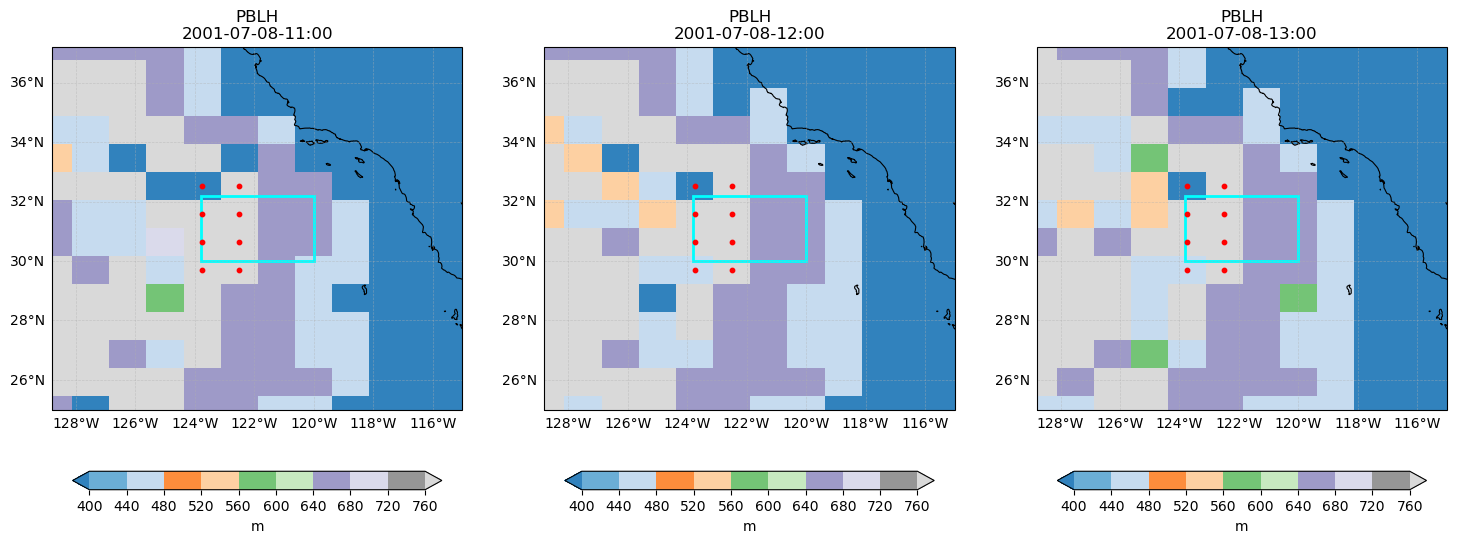

In [107]:
tt=time_idxes[0]
da1 = ds_2d_1hr["PBLH"][tt-1,:,:]
da2 = ds_2d_1hr["PBLH"][tt,:,:]
da3 = ds_2d_1hr["PBLH"][tt+1,:,:]

map_projection = ccrs.PlateCarree(central_longitude=0)
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 10),
    subplot_kw={"projection": map_projection},
)

#method="contourf"
method="pcolormesh"

map_settings = {
    "method": method,
    "cmap": "tab20c",
    "extent": get_region_extent("DYCOMS", padding=5),
    "levels": np.arange(400, 800, 40),
}

cf1, _ = plot_cn_map(
    axes[0],
    da1,
    **map_settings,
)

cf2, _ = plot_cn_map(
    axes[1],
    da2,
    **map_settings,
)

cf2, _ = plot_cn_map(
    axes[2],
    da3,
    **map_settings,
)

for ax in axes.flat:
    plot_box(ax, "DYCOMS")

for ax in axes.flat:
    plot_points(ax, ds_region, color="red")

## plot - CLDLIQ

In [65]:
#str(ds_state_3hr["Z3"][itime, ilev-1, ilat, ilon].values)

In [66]:
itime, ilev, ilat, ilon = find_nearest_indices(
    da=ds_state_3hr["Z3"],
    target_value=600.0,
    time=time_00,
    lat=31.5,
    lon=238.0,
)

print(itime, ilev, ilat, ilon)

12 26 12 14


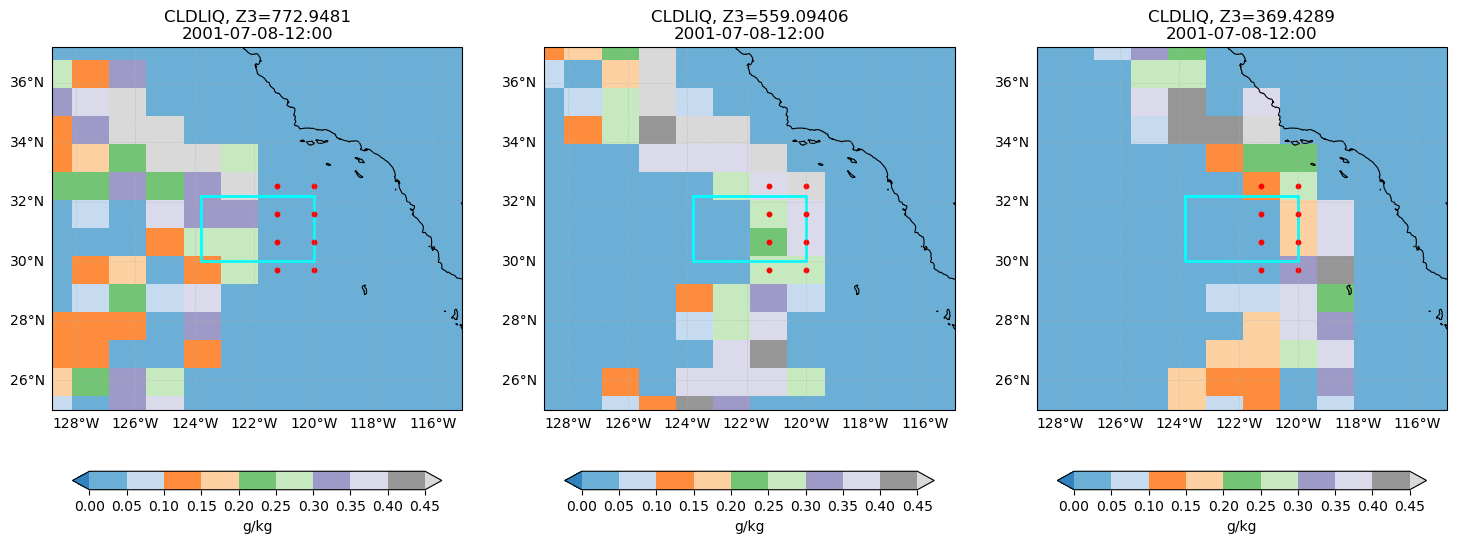

In [95]:
#tt=35
#kk=27
varname = "CLDLIQ"

da1 = ds_state_3hr[varname][itime,ilev-1,:,:]
title1 = varname + ", Z3=" + str(ds_state_3hr["Z3"][itime, ilev-1, ilat, ilon].values)
da2 = ds_state_3hr[varname][itime,ilev,:,:]
title2 = varname + ", Z3=" + str(ds_state_3hr["Z3"][itime, ilev, ilat, ilon].values)
da3 = ds_state_3hr[varname][itime,ilev+1,:,:]
title3 = varname + ", Z3=" + str(ds_state_3hr["Z3"][itime, ilev+1, ilat, ilon].values)

da1 = yhc.unit_convert (da1)
da2 = yhc.unit_convert (da2)
da3 = yhc.unit_convert (da3)


map_projection = ccrs.PlateCarree(central_longitude=0)
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 10),
    subplot_kw={"projection": map_projection},
)

#method="contourf"
method="pcolormesh"

map_settings = {
    "method": method,
    "cmap": "tab20c",
    "extent": get_region_extent("DYCOMS", padding=5),
    "levels": np.arange(0, 0.5, 0.05),
    #"levels": np.arange(0, 1.e-3, 1.e-4),
    #"title": f"{varname}, k_idx={kk}"
}

cf1, _ = plot_cn_map(
    axes[0],
    da1,
    title=title1,
    **map_settings,
)

cf2, _ = plot_cn_map(
    axes[1],
    da2,
    title=title2,
    **map_settings,
)

cf2, _ = plot_cn_map(
    axes[2],
    da3,
    title=title3,
    **map_settings,
)

for ax in axes.flat:
    plot_box(ax, "DYCOMS")

for ax in axes.flat:
    plot_points(ax, ds_region, color="red")

## plot - DYCOMS region

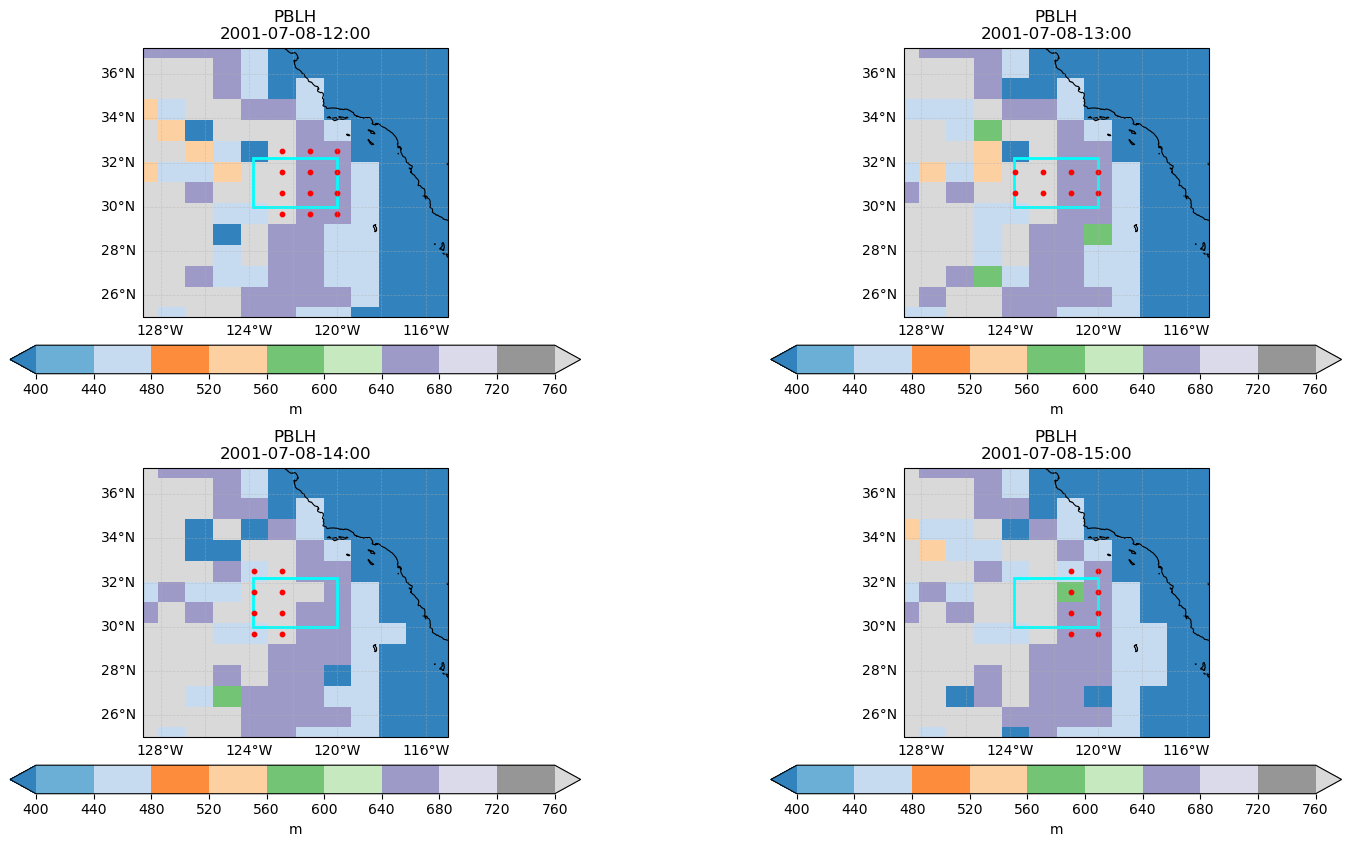

In [115]:
tt=time_idxes[0]
da1 = ds_2d_1hr["PBLH"][tt,:,:]
da2 = ds_2d_1hr["PBLH"][tt+1,:,:]
da3 = ds_2d_1hr["PBLH"][tt+2,:,:]
da4 = ds_2d_1hr["PBLH"][tt+3,:,:]

map_projection = ccrs.PlateCarree(central_longitude=0)
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 10),
    subplot_kw={"projection": map_projection},
)

#method="contourf"
method="pcolormesh"

map_settings = {
    "method": method,
    "cmap": "tab20c",
    "extent": get_region_extent("DYCOMS", padding=5),
    "levels": np.arange(400, 800, 40),
}

cf1, _ = plot_cn_map(
    axes[0,0],
    da1,
    **map_settings,
)

cf2, _ = plot_cn_map(
    axes[0,1],
    da2,
    **map_settings,
)

cf2, _ = plot_cn_map(
    axes[1,0],
    da3,
    **map_settings,
)

cf2, _ = plot_cn_map(
    axes[1,1],
    da4,
    **map_settings,
)

for ax in axes.flat:
    plot_box(ax, "DYCOMS")

#ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_entire")
ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS")
plot_points(axes[0,0], ds_region, color="red")

ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_small")
plot_points(axes[0,1], ds_region, color="red")

ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_entire_west")
plot_points(axes[1,0], ds_region, color="red")

ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_entire_east")
plot_points(axes[1,1], ds_region, color="red")

#ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_entire")
#ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_entire_east")
#ds_region = select_region_ds(ds_2d_1hr, region="DYCOMS_small")

#for ax in axes.flat:
#    plot_points(ax, ds_region, color="red")